In [30]:
import pandas as pd
import numpy as np 
import joblib
import yaml
import warnings
warnings.filterwarnings('ignore')

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_validate
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer
from sklearn.calibration import CalibratedClassifierCV

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Libraries loaded')

Libraries loaded


In [8]:
df = pd.read_csv('../../data/processed/youtoxic_preprocessed.csv')

X = df['Text'].astype(str)
y = df['IsToxic'].astype(int)

print(f'Shape : {df.shape}')
print(f'Class distribution:\n {y.value_counts()}')
print(f'Positivo class ratio: {y.mean():.2%}')

Shape : (962, 2)
Class distribution:
 IsToxic
0    516
1    446
Name: count, dtype: int64
Positivo class ratio: 46.36%


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

f1_scorer = make_scorer(f1_score)

print('validation: StratifiedKFold k=5')
print('Objective: maximize Test F1 with gap < 0.05')

validation: StratifiedKFold k=5
Objective: maximize Test F1 with gap < 0.05


In [ ]:
def objective(trial):
    
    max_features = trial.suggest_int('max_features', 200, 5000, step=200)
    min_df       = trial.suggest_int('min_df', 2, 15)
    ngram_max    = trial.suggest_categorical('ngram_max', [1, 2])
    sublinear_tf = trial.suggest_categorical('sublinear_tf', [True, False])

    tfidf = TfidfVectorizer(
        ngram_range=(1, ngram_max),
        max_features=max_features,
        min_df=min_df,
        sublinear_tf=sublinear_tf
    )

    
    model_name = trial.suggest_categorical('model', [
        'LogisticRegression',
        'LinearSVC',
        'RidgeClassifier',
        'SGDClassifier',
        'PassiveAggressive'
    ])

    if model_name == 'LogisticRegression':
        C = trial.suggest_float('C', 0.001, 10.0, log=True)
        clf = LogisticRegression(
            C=C, class_weight='balanced',
            solver='lbfgs', max_iter=1000,
            random_state=RANDOM_STATE
        )
    elif model_name == 'LinearSVC':
        C = trial.suggest_float('C_svc', 0.001, 10.0, log=True)
        clf = CalibratedClassifierCV(
            LinearSVC(C=C, class_weight='balanced', random_state=RANDOM_STATE)
        )
    elif model_name == 'RidgeClassifier':
        alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
        clf = RidgeClassifier(alpha=alpha, class_weight='balanced')
    elif model_name == 'SGDClassifier':
        alpha = trial.suggest_float('alpha_sgd', 0.0001, 1.0, log=True)
        clf = SGDClassifier(
            loss='hinge', alpha=alpha,
            class_weight='balanced',
            random_state=RANDOM_STATE
        )
    else:  # PassiveAggressive
        C = trial.suggest_float('C_pa', 0.001, 10.0, log=True)
        clf = PassiveAggressiveClassifier(
            C=C, class_weight='balanced',
            random_state=RANDOM_STATE
        )

    pipeline = Pipeline([
        ('tfidf', tfidf),
        ('clf', clf)
    ])

    # Cross-validation scores
    train_scores = cross_val_score(pipeline, X, y, cv=cv,
                                scoring=f1_scorer,
                                n_jobs=-1)

    cv_results = cross_validate(pipeline, X, y, cv=cv,
                                scoring=f1_scorer,
                                return_train_score=True,
                                n_jobs=-1)

    train_f1 = cv_results['train_score'].mean()
    test_f1  = cv_results['test_score'].mean()
    gap      = train_f1 - test_f1


    trial.set_user_attr('train_f1', round(train_f1, 4))
    trial.set_user_attr('test_f1',  round(test_f1, 4))
    trial.set_user_attr('gap',      round(gap, 4))

    # Penalize if gap > 0.05
    if gap > 0.05:
        return test_f1 - (gap - 0.05) * 2

    return test_f1


print('Objective function defined')

Objective function defined


In [23]:
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='hate-speech-classifier'
)

print('Runing 100 trial - this may take a few minutes...')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print('\n Optuna finished')
print(f'Best trial: #{study.best_trial.number}')
print(f'Best value: {study.best_value:.4f}')
print(f'\nBest params: ')
for k, v in study.best_params.items():
    print(f' {k}: {v}')

print(f'\nBest trial attrs: ')
print(f' Trian F1: {study.best_trial.user_attrs['train_f1']}')
print(f' Test F1 : {study.best_trial.user_attrs['test_f1']}')
print(f' Gap     : {study.best_trial.user_attrs['gap']}')


Runing 100 trial - this may take a few minutes...


Best trial: 76. Best value: 0.659639: 100%|██████████| 100/100 [00:17<00:00,  5.62it/s]


 Optuna finished
Best trial: #76
Best value: 0.6596

Best params: 
 max_features: 4800
 min_df: 15
 ngram_max: 1
 sublinear_tf: True
 model: SGDClassifier
 alpha_sgd: 0.023383932702137865

Best trial attrs: 
 Trian F1: 0.7476
 Test F1 : 0.685
 Gap     : 0.0627


In [ ]:
trials_data = []
for trial in study.trials:
    if trial.state == optuna.trial.TrialState.COMPLETE:
        row = {
            'trial' :    trial.number,
            'value':    round(trial.value, 4),
            'train_f1': trial.user_attrs.get('train_f1', None),
            'test_f1':  trial.user_attrs.get('test_f1', None),
            'gap':      trial.user_attrs.get('gap', None),
            'model':    trial.params.get('model', None),
        }
        row.update(trial.params)
        trials_data.append(row)

trials_df = pd.DataFrame(trials_data)

# Trials passing gap requirement
passed = trials_df[trials_df['gap'].astype(float) < 0.05]
print(f'Trials passing gap < 0.05: {len(passed)} / {len(trials_df)}')

if len(passed) > 0:
    print('\n=== TOP 5 PASSING TRIALS ===')
    print(passed.sort_values('test_f1', ascending=False)[
        ['trial', 'model', 'train_f1', 'test_f1', 'gap']
    ].head(5).to_string())
else:
    print('\n No trial passed gap requirement')
    print('\n=== TOP 5 BY TEST F1 ===')
    print(trials_df.sort_values('test_f1', ascending=False)[
        ['trial', 'model', 'train_f1', 'test_f1', 'gap']
    ].head(5).to_string())

Trials passing gap < 0.05: 1 / 100

=== TOP 5 PASSING TRIALS ===
    trial          model  train_f1  test_f1     gap
36     36  SGDClassifier    0.6126   0.5721  0.0405


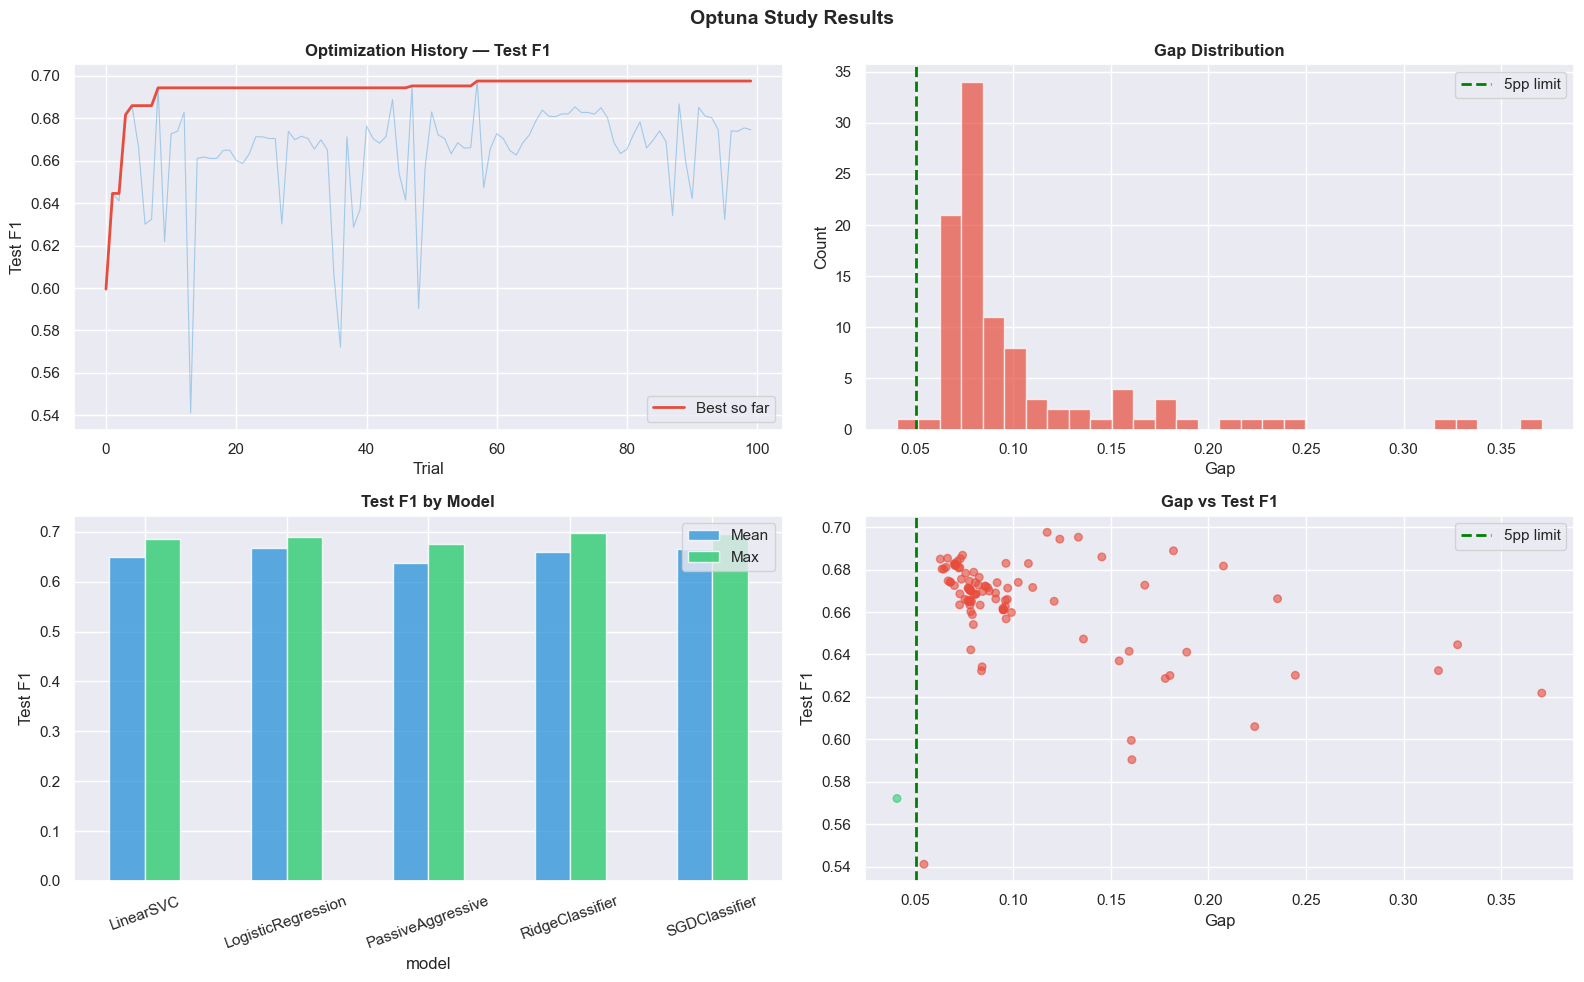

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Optimization history
axes[0,0].plot(trials_df['trial'], trials_df['test_f1'],
            alpha=0.4, color='#3498db', linewidth=0.8)
axes[0,0].plot(trials_df['trial'],
            trials_df['test_f1'].cummax(),
            color='#e74c3c', linewidth=2, label='Best so far')
axes[0,0].set_title('Optimization History — Test F1', fontweight='bold')
axes[0,0].set_xlabel('Trial')
axes[0,0].set_ylabel('Test F1')
axes[0,0].legend()

# Gap distribution
axes[0,1].hist(trials_df['gap'].astype(float), bins=30,
                color='#e74c3c', alpha=0.7)
axes[0,1].axvline(x=0.05, color='green', linestyle='--',
                linewidth=2, label='5pp limit')
axes[0,1].set_title('Gap Distribution', fontweight='bold')
axes[0,1].set_xlabel('Gap')
axes[0,1].set_ylabel('Count')
axes[0,1].legend()

# Test F1 by model
if 'model' in trials_df.columns:
    model_results = trials_df.groupby('model')['test_f1'].agg(['mean', 'max'])
    model_results.plot(kind='bar', ax=axes[1,0],
                        color=['#3498db', '#2ecc71'], alpha=0.8)
    axes[1,0].set_title('Test F1 by Model', fontweight='bold')
    axes[1,0].set_ylabel('Test F1')
    axes[1,0].tick_params(axis='x', rotation=20)
    axes[1,0].legend(['Mean', 'Max'])

# Gap vs Test F1 scatter
scatter_colors = ['#2ecc71' if g < 0.05 else '#e74c3c'
                    for g in trials_df['gap'].astype(float)]
axes[1,1].scatter(trials_df['gap'].astype(float),
                    trials_df['test_f1'].astype(float),
                    c=scatter_colors, alpha=0.6, s=30)
axes[1,1].axvline(x=0.05, color='green', linestyle='--',
                    linewidth=2, label='5pp limit')
axes[1,1].set_title('Gap vs Test F1', fontweight='bold')
axes[1,1].set_xlabel('Gap')
axes[1,1].set_ylabel('Test F1')
axes[1,1].legend()

plt.suptitle('Optuna Study Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
best_params = study.best_params
best_attrs  = study.best_trial.user_attrs

print('=== BEST CONFIGURATION ===')
print(f'  Model:    {best_params.get("model")}')
print(f'  Train F1: {best_attrs["train_f1"]}')
print(f'  Test F1:  {best_attrs["test_f1"]}')
print(f'  Gap:      {best_attrs["gap"]}')
print(f'  Params:   {best_params}')


ngram_max    = best_params.get('ngram_max', 1)
max_features = best_params.get('max_features', 2000)
min_df       = best_params.get('min_df', 5)
sublinear_tf = best_params.get('sublinear_tf', True)
model_name   = best_params.get('model', 'LogisticRegression')

best_tfidf = TfidfVectorizer(
    ngram_range=(1, ngram_max),
    max_features=max_features,
    min_df=min_df,
    sublinear_tf=sublinear_tf
)

if model_name == 'LogisticRegression':
    best_clf = LogisticRegression(
        C=best_params.get('C', 0.1),
        class_weight='balanced',
        solver='lbfgs', max_iter=1000,
        random_state=RANDOM_STATE
    )
elif model_name == 'LinearSVC':
    best_clf = CalibratedClassifierCV(
        LinearSVC(C=best_params.get('C_svc', 0.01),
                    class_weight='balanced',
                    random_state=RANDOM_STATE)
    )
elif model_name == 'RidgeClassifier':
    best_clf = RidgeClassifier(
        alpha=best_params.get('alpha', 1.0),
        class_weight='balanced'
    )
elif model_name == 'SGDClassifier':
    best_clf = SGDClassifier(
        loss='hinge',
        alpha=best_params.get('alpha_sgd', 0.001),
        class_weight='balanced',
        random_state=RANDOM_STATE
    )
else:
    best_clf = PassiveAggressiveClassifier(
        C=best_params.get('C_pa', 0.01),
        class_weight='balanced',
        random_state=RANDOM_STATE
    )

best_pipeline = Pipeline([
    ('tfidf', best_tfidf),
    ('clf', best_clf)
])

best_pipeline.fit(X, y)
joblib.dump(best_pipeline, '../../models/saved/best_model_optuna.pkl')

print('\nSaved: models/saved/best_model_optuna.pkl')

test_texts = [
    'I hate you so much you are the worst',
    'This is a great video thank you for sharing',
    'you are a fucking idiot go back to your country',
]
print('\n=== Quick prediction test ===')
for text in test_texts:
    pred = best_pipeline.predict([text])[0]
    label = 'TOXIC' if pred == 1 else 'NOT TOXIC'
    print(f'  {label} → "{text}"')

=== BEST CONFIGURATION ===
  Model:    SGDClassifier
  Train F1: 0.7476
  Test F1:  0.685
  Gap:      0.0627
  Params:   {'max_features': 4800, 'min_df': 15, 'ngram_max': 1, 'sublinear_tf': True, 'model': 'SGDClassifier', 'alpha_sgd': 0.023383932702137865}

Saved: models/saved/best_model_optuna.pkl

=== Quick prediction test ===
  NOT TOXIC → "I hate you so much you are the worst"
  NOT TOXIC → "This is a great video thank you for sharing"
  TOXIC → "you are a fucking idiot go back to your country"


In [32]:

best_config = {
    'model': {
        'name':       best_params.get('model'),
        'train_f1':   best_attrs['train_f1'],
        'test_f1':    best_attrs['test_f1'],
        'gap':        best_attrs['gap'],
        'params':     best_params,
    },
    'tfidf': {
        'max_features': best_params.get('max_features'),
        'min_df':       best_params.get('min_df'),
        'ngram_range':  [1, best_params.get('ngram_max', 1)],
        'sublinear_tf': best_params.get('sublinear_tf'),
    }
}

with open('../../configs/model_config.yaml', 'w') as f:
    yaml.dump(best_config, f, default_flow_style=False)

print('Saved: configs/model_config.yaml')
print(yaml.dump(best_config, default_flow_style=False))

Saved: configs/model_config.yaml
model:
  gap: !!python/object/apply:numpy._core.multiarray.scalar
  - &id001 !!python/object/apply:numpy.dtype
    args:
    - f8
    - false
    - true
    state: !!python/tuple
    - 3
    - <
    - null
    - null
    - null
    - -1
    - -1
    - 0
  - !!binary |
    Io51cRsNsD8=
  name: SGDClassifier
  params:
    alpha_sgd: 0.023383932702137865
    max_features: 4800
    min_df: 15
    model: SGDClassifier
    ngram_max: 1
    sublinear_tf: true
  test_f1: !!python/object/apply:numpy._core.multiarray.scalar
  - *id001
  - !!binary |
    7FG4HoXr5T8=
  train_f1: !!python/object/apply:numpy._core.multiarray.scalar
  - *id001
  - !!binary |
    zqrP1Vbs5z8=
tfidf:
  max_features: 4800
  min_df: 15
  ngram_range:
  - 1
  - 1
  sublinear_tf: true



In [ ]:
gap_val = float(best_attrs['gap'])git 
conclusions = {
    'Trials run':      '100 — TPE sampler',
    'Best model':      best_params.get('model'),
    'Best Test F1':    best_attrs['test_f1'],
    'Best Train F1':   best_attrs['train_f1'],
    'Best gap':        f"{best_attrs['gap']} ({float(best_attrs['gap'])*100:.1f}pp)",
    'Gap resolved':    'Yes' if gap_val < 0.05 else f'No — {gap_val*100:.1f}pp vs limit 5pp (improved from 15pp)',
    'Models searched': '5 — LR, LinearSVC, Ridge, SGD, PassiveAggressive',
    'Search space':    'max_features, min_df, ngram, C/alpha per model',
    'Conclusion':      'Classical ML ceiling reached — transformer needed for F1 > 0.75',
    'Next step':       'interface — Streamlit app' if gap_val < 0.05 else 'transformer — DistilBERT fine-tuned on YouToxic',
}
print('=== OPTUNA CONCLUSIONS ===')
for k, v in conclusions.items():
    print(f'  {k:20s} → {v}')

=== OPTUNA CONCLUSIONS ===
  Trials run           → 100 — TPE sampler
  Best model           → SGDClassifier
  Best Test F1         → 0.685
  Best Train F1        → 0.7476
  Best gap             → 0.0627 (6.3pp)
  Gap resolved         → No — 6.3pp vs limit 5pp (improved from 15pp)
  Models searched      → 5 — LR, LinearSVC, Ridge, SGD, PassiveAggressive
  Search space         → max_features, min_df, ngram, C/alpha per model
  Conclusion           → Classical ML ceiling reached — transformer needed for F1 > 0.75
  Next step            → transformer — DistilBERT fine-tuned on YouToxic
